
# Mock Data + Multi-Output GP Regression

In [1]:
import sys
from pathlib import Path

project_root = Path(r"c:\Users\floki\PycharmProjects\dash-azure-prototype")
src_root = project_root / "src"
for p in (project_root, src_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
artifact_dir = project_root / "ml" / "models" / "artifacts" / "demo_gpr"
artifact_dir.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [3]:
from ml.scripts.plotting import (
    plot_true_vs_predicted,
    plot_pca_cumulative_variance,
    plot_pca_loadings,
    plot_scaler_hist,
)
from ml.scripts.trainers import GPRTrainer
from ml.scripts.log import init_ml_logger, log_data_summary
from worker.models import GPR
from worker.models.specs import ModelConfig, PreprocessConfig, AuxilaryData
from worker.models.io_utils import ArtifactIO
from worker.torch_utils import get_default_device
from worker.scalers import LogTransformer

In [4]:
# load demo data for testing
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(data_url)
df = df.rename(columns=lambda c: str(c).strip())
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
# train test split
feature_cols = list(df.columns[:8])
target_cols = list(df.columns[8:10])

df = df.dropna(subset=feature_cols, how="any", axis=0)
df = df.dropna(subset=target_cols, how="all", axis=0)
df = df.drop_duplicates(subset=feature_cols, keep="first", ignore_index=True)
df = df.reset_index(drop=True)

X = df[feature_cols].to_numpy()
y = df[target_cols].to_numpy()

train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.1, random_state=1, shuffle=True,
)

train_x_raw = train_x.copy()
test_x_raw = test_x.copy()
train_y_raw = train_y.copy()
test_y_raw = test_y.copy()

In [6]:
# drop features without variance
var_x = VarianceThreshold(threshold=1e-6)
train_x = var_x.fit_transform(train_x)
test_x = var_x.transform(test_x)
train_x_raw = var_x.transform(train_x_raw)
test_x_raw = var_x.transform(test_x_raw)
kept_mask_x = var_x.get_support()
feature_cols = [c for c, keep in zip(feature_cols, kept_mask_x) if keep]

In [7]:
# feature scaling
scaler_x = StandardScaler()
train_x = scaler_x.fit_transform(train_x)
test_x = scaler_x.transform(test_x)

In [8]:
# target scaling
scaler_y = StandardScaler()
train_y = scaler_y.fit_transform(train_y)
test_y = scaler_y.transform(test_y)

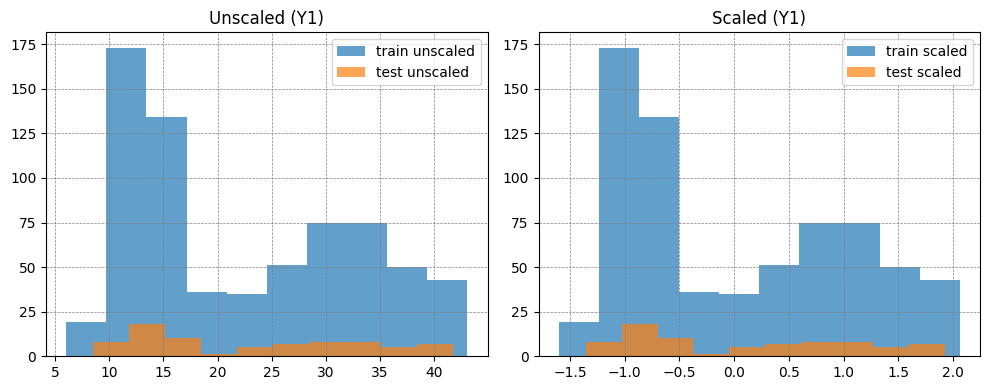

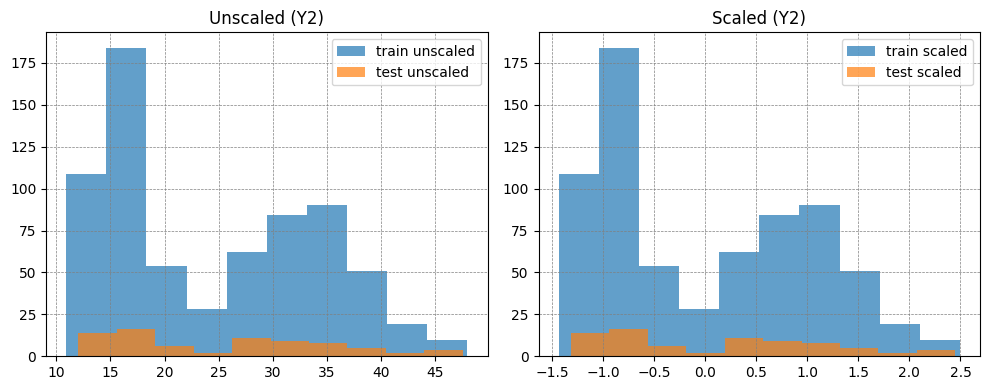

In [9]:
# scaler diagnostics
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_scaler_hist(scaler_y, train_y_raw, test_y_raw, target_cols, filepath=plots_dir / "scaling")

In [10]:
# PCA fit/transform
pca_x = PCA(whiten=False, n_components=0.999, random_state=1)
train_x = pca_x.fit_transform(train_x)
test_x = pca_x.transform(test_x)

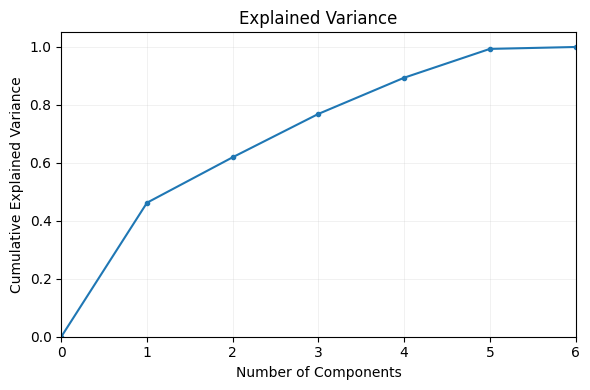

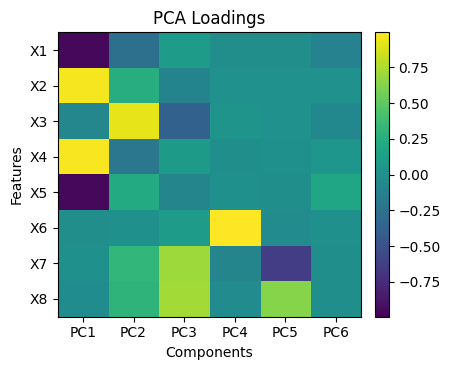

In [11]:
# PCA diagnostics
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_pca_cumulative_variance(pca=pca_x, filepath=plots_dir / "pca_cumvar.png")
plot_pca_loadings(pca=pca_x, feature_names=feature_cols, filepath=plots_dir / "pca_loadings.png")
explained_variance = float(pca_x.explained_variance_ratio_.sum())

In [12]:
# setup model
prep = PreprocessConfig(scaler_x=scaler_x, pca_x=pca_x, scaler_y=scaler_y)
noise_rank = 1
covar_rank = 1
spec = ModelConfig(
    model_type="gpr",
    features=feature_cols,
    targets=target_cols,
    requires_aux=True,
    model_kwargs={"covar_rank": covar_rank, "noise_rank": noise_rank},
)
aux = AuxilaryData(train_x=train_x, train_y=train_y)
model = GPR(spec, prep, aux)

In [13]:
# conduct training
device = get_default_device()
print(f"Running on {str(device)}")
trainer = GPRTrainer(model, device=device, lr=0.01)
metrics = trainer.train(train_x, train_y, epochs=600)

Running on cuda


GP training:   0%|          | 0/600 [00:00<?, ?it/s]

In [14]:
# check if storing / loading of artifacts works
ArtifactIO.save(artifact_dir, model=model, spec=spec, prep=prep, aux=aux)
loaded_model = ArtifactIO.load(artifact_dir, device=device)

In [15]:
# test predictions on test set
preds = loaded_model.predict(test_x_raw, device=device, return_std=True)
pred_mean = preds.get('mean')
pred_std = preds.get('std')

preds_train = loaded_model.predict(train_x_raw, device=device, return_std=True)
pred_mean_train = preds_train.get('mean')
pred_std_train = preds_train.get('std')

In [16]:
logger, _ = init_ml_logger(artifact_dir, "training")
if logger is not None:
    logger.info("PCA Cumulative Variance (train): %.4f", explained_variance)
    logger.info("Train time (s): %.3f", trainer.duration)
    log_data_summary(
        logger,
        train_y_raw,
        y_pred=pred_mean_train,
        y_std=pred_std_train,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Train",
    )
    log_data_summary(
        logger,
        test_y_raw,
        y_pred=pred_mean,
        y_std=pred_std,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Test",
    )

2026-04-03 09:44:43,900 | INFO | PCA Cumulative Variance (train): 0.9994
2026-04-03 09:44:43,901 | INFO | Train time (s): 86.491
2026-04-03 09:44:43,902 | INFO | Train: n_obs=691 n_features=8 n_targets=2 non_nan_targets=1382
2026-04-03 09:44:43,904 | INFO | Train metrics per target:
2026-04-03 09:44:43,906 | INFO |   Y1 | R2=0.9986 MAPE=0.0133 PICP(95%)=0.9986
2026-04-03 09:44:43,909 | INFO |   Y2 | R2=0.9918 MAPE=0.0181 PICP(95%)=0.9508
2026-04-03 09:44:43,909 | INFO | Test: n_obs=77 n_features=8 n_targets=2 non_nan_targets=154
2026-04-03 09:44:43,910 | INFO | Test metrics per target:
2026-04-03 09:44:43,911 | INFO |   Y1 | R2=0.9963 MAPE=0.0204 PICP(95%)=1.0000
2026-04-03 09:44:43,913 | INFO |   Y2 | R2=0.9812 MAPE=0.0295 PICP(95%)=0.9221


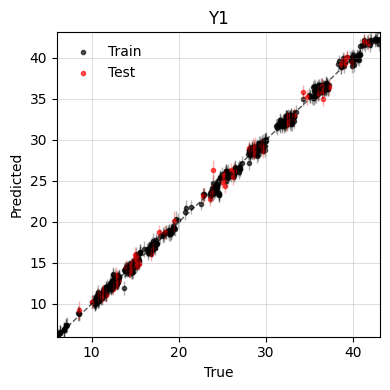

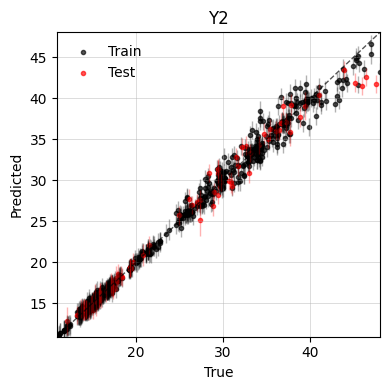

In [17]:
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_true_vs_predicted(
    train_y_raw,
    pred_mean_train,
    y_std=pred_std_train,
    y_true_test=test_y_raw,
    y_pred_test=pred_mean,
    y_std_test=pred_std,
    target_cols=target_cols,
    show_std=pred_std is not None or pred_std_train is not None,
    filepath=plots_dir / "results",
)

In [18]:
# Outlier + summary export (unscaled)
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score
from ml.scripts.metrics import mape, picp
from ml.scripts.outliers import build_outliers_dataframe, save_outliers_csv

reports_dir = artifact_dir / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

_pred_std_train = pred_std_train if "pred_std_train" in globals() else None
_pred_std = pred_std if "pred_std" in globals() else None

def _metrics_table(y_true, y_pred, y_std, target_cols, coverage=0.95):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = None if y_pred is None else np.asarray(y_pred, dtype=float)
    y_std = None if y_std is None else np.asarray(y_std, dtype=float)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred is not None and y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    if y_std is not None and y_std.ndim == 1:
        y_std = y_std.reshape(-1, 1)

    labels = target_cols or [f"y{i}" for i in range(y_true.shape[1])]
    rows = []
    for i, name in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i] if y_pred is not None else None
        ys = y_std[:, i] if y_std is not None else None

        mask = ~np.isnan(yt)
        if yp is not None:
            mask &= ~np.isnan(yp)
        if ys is not None:
            mask &= ~np.isnan(ys)

        yt = yt[mask]
        yp = yp[mask] if yp is not None else None
        ys = ys[mask] if ys is not None else None

        r2_val = np.nan
        if yp is not None and yt.size >= 2:
            try:
                r2_val = r2_score(yt, yp)
            except Exception:
                pass

        mape_val = np.nan
        if yp is not None and yt.size > 0:
            try:
                mape_val = float(mape(
                    yt.reshape(-1, 1),
                    y_pred=yp.reshape(-1, 1),
                    multioutput="raw_values",
                )[0])
            except Exception:
                pass

        picp_val = np.nan
        if yp is not None and ys is not None and yt.size > 0:
            try:
                picp_val = float(picp(
                    yt.reshape(-1, 1),
                    y_pred=yp.reshape(-1, 1),
                    y_std=ys.reshape(-1, 1),
                    multioutput="raw_values",
                )[0])
            except Exception:
                pass

        rows.append({"target": name, "r2": r2_val, "mape": mape_val, "picp": picp_val})

    return pd.DataFrame(rows)

metrics_train = _metrics_table(train_y_raw, pred_mean_train, _pred_std_train, target_cols)
metrics_train["phase"] = "Train"
metrics_test = _metrics_table(test_y_raw, pred_mean, _pred_std, target_cols)
metrics_test["phase"] = "Test"
metrics_df = pd.concat([metrics_train, metrics_test], ignore_index=True)
metrics_df.to_csv(reports_dir / "metrics_summary.csv", index=False)

summary_train = build_outliers_dataframe(
    train_x_raw,
    train_y_raw,
    y_pred=pred_mean_train,
    y_std=_pred_std_train,
    feature_cols=feature_cols,
    target_cols=target_cols,
    phase="Train",
    include_all=True,
)
summary_test = build_outliers_dataframe(
    test_x_raw,
    test_y_raw,
    y_pred=pred_mean,
    y_std=_pred_std,
    feature_cols=feature_cols,
    target_cols=target_cols,
    phase="Test",
    include_all=True,
)
summary_df = pd.concat([summary_train, summary_test], ignore_index=True)
summary_df.to_csv(reports_dir / "predictions_summary.csv", index=False)

if "outlier_any" in summary_df.columns:
    outliers_df = summary_df[summary_df["outlier_any"]].copy()
else:
    outliers_df = summary_df.head(0).copy()

save_outliers_csv(reports_dir / "outliers.csv", outliers_df)

print(f"Summary rows: {len(summary_df)} | Outliers: {len(outliers_df)}")
display(metrics_df.head())
display(outliers_df.head())


Summary rows: 768 | Outliers: 41


,target,r2,mape,picp,phase
0,Y1,0.998624,0.013298,0.998553,Train
1,Y2,0.991783,0.018128,0.950796,Train
2,Y1,0.996295,0.020449,1.000000,Test
3,Y2,0.981174,0.029468,0.922078,Test


,row_index,phase,X1,X2,X3,X4,X5,X6,X7,X8,...,lower_Y2,upper_Y2,abs_err_Y1,pct_err_Y1,abs_err_Y2,pct_err_Y2,outside_Y1,outside_Y2,outlier_any,outlier_count
16,16,Train,0.90,563.5,318.5,122.5,7.0,5.0,0.40,3.0,...,33.927716,38.290282,0.709706,0.020697,2.798999,0.084029,False,True,True,1
56,56,Train,0.79,637.0,343.0,147.0,7.0,3.0,0.40,3.0,...,39.688313,43.930680,0.808456,0.019575,2.370504,0.053656,False,True,True,1
61,61,Train,0.79,637.0,343.0,147.0,7.0,2.0,0.25,4.0,...,36.844065,41.129424,0.474444,0.011861,2.726744,0.075200,False,True,True,1
76,76,Train,0.79,637.0,343.0,147.0,7.0,5.0,0.40,3.0,...,39.146096,43.381495,0.108814,0.002586,3.033795,0.079356,False,True,True,1
79,79,Train,0.79,637.0,343.0,147.0,7.0,3.0,0.10,3.0,...,37.083251,41.214621,1.107372,0.031211,2.071064,0.050244,False,True,True,1
